# Factor stability of the Cell-Cell Communication analysis

## Introduction

Here we test factor stability by re-running NMF decomposition.

## Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import liana as li
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

## Load data

In [2]:
nmf_dir = os.path.join('out', 'nmf')
nmfdatas = {}

for fname in os.listdir(nmf_dir):
    if fname.endswith('.h5ad'):
        seed = fname.replace('.h5ad', '')
        nmfdatas[seed] = sc.read_h5ad(os.path.join(nmf_dir, fname))

## Factor stability analysis

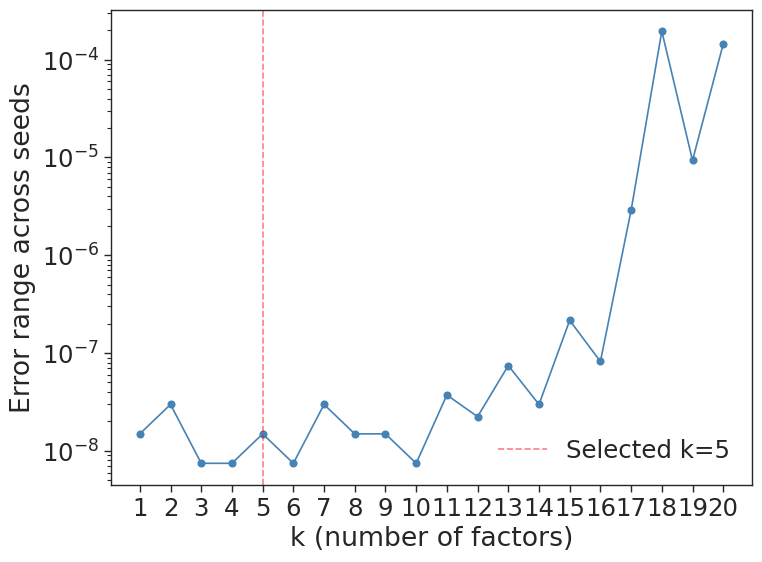

        mean           std       min       max         range    cv_pct
k                                                                     
1   0.126775  6.027816e-09  0.126775  0.126775  1.490116e-08  0.000005
2   0.102831  8.700404e-09  0.102831  0.102831  2.980232e-08  0.000008
3   0.089371  3.890939e-09  0.089371  0.089371  7.450581e-09  0.000004
4   0.085856  2.246435e-09  0.085856  0.085856  7.450581e-09  0.000003
5   0.082359  5.593577e-09  0.082359  0.082359  1.490116e-08  0.000007
6   0.079702  3.480161e-09  0.079702  0.079702  7.450581e-09  0.000004
7   0.077602  9.477718e-09  0.077602  0.077602  2.980232e-08  0.000012
8   0.075486  7.518008e-09  0.075486  0.075486  1.490116e-08  0.000010
9   0.073266  5.023181e-09  0.073266  0.073266  1.490116e-08  0.000007
10  0.071676  3.890939e-09  0.071676  0.071676  7.450581e-09  0.000005
11  0.069978  1.171597e-08  0.069978  0.069978  3.725290e-08  0.000017
12  0.068538  6.960323e-09  0.068538  0.068538  2.235174e-08  0.000010
13  0.

In [3]:
k_values = nmfdatas[list(nmfdatas.keys())[0]].uns['nmf_errors']['k'].values
error_table = pd.DataFrame(
    {seed: lrdata.uns['nmf_errors']['error'].values for seed, lrdata in nmfdatas.items()},
    index=k_values
)
error_table.index.name = 'k'

summary = pd.DataFrame({
    'mean': error_table.mean(axis=1),
    'std': error_table.std(axis=1),
    'min': error_table.min(axis=1),
    'max': error_table.max(axis=1),
    'range': error_table.max(axis=1) - error_table.min(axis=1),
    'cv_pct': 100 * error_table.std(axis=1) / error_table.mean(axis=1)  
})

sns.set_theme(style="ticks", context="paper", font_scale=2)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(summary.index, summary['range'], marker='o', color='steelblue')
ax.axvline(x=5, linestyle='--', color='red', alpha=0.5, label='Selected k=5')
ax.set_xlabel('k (number of factors)')
ax.set_ylabel('Error range across seeds')
ax.set_yscale('log')
ax.set_xticks(range(1, 21))  
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("out/plots/stability_range.svg", bbox_inches = "tight")
plt.show()

pd.set_option('display.width', 200)
print(summary)

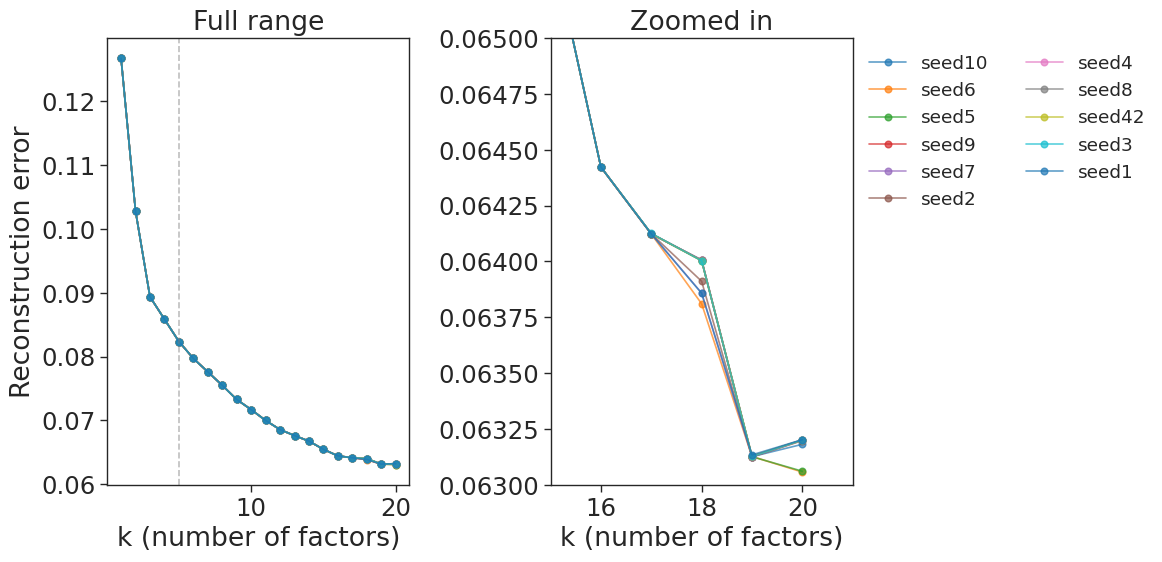

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharex=False)

colors = sns.color_palette("tab10", len(nmfdatas))

for (seed, lrdata_all), color in zip(nmfdatas.items(), colors):
    errors = lrdata_all.uns['nmf_errors']
    ax1.plot(errors['k'], errors['error'], marker='o', color=color, label=seed, alpha=0.7)
ax1.axvline(x=5, linestyle='--', color='gray', alpha=0.5)
ax1.set_ylabel('Reconstruction error')
ax1.set_xlabel('k (number of factors)')
ax1.set_title('Full range')

for (seed, lrdata_all), color in zip(nmfdatas.items(), colors):
    errors = lrdata_all.uns['nmf_errors']
    ax2.plot(errors['k'], errors['error'], marker='o', color=color, label=seed, alpha=0.7)
ax2.axvline(x=5, linestyle='--', color='gray', alpha=0.5)
ax2.set_xlabel('k (number of factors)')
ax2.set_title('Zoomed in')
ax2.set_ylim(0.063, 0.065)
ax2.set_xlim(15, 21)

ax2.legend(frameon=False, fontsize='x-small', ncol=2, loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.savefig("out/plots/stability_error.svg", bbox_inches = "tight")
plt.show()

In [5]:
def compute_factor_stability(nmfdatas, n_factors=5, reference_seed=None):
    seeds = list(nmfdatas.keys())
    reference_seed = reference_seed

    all_loadings = {}
    ref_lr_index = None
    for seed, adata in nmfdatas.items():
        loadings = li.ut.get_variable_loadings(adata, varm_key='NMF_H').set_index('index')
        if ref_lr_index is None:
            ref_lr_index = loadings.index
        loadings = loadings.reindex(ref_lr_index)
        factor_cols = [f'Factor{i+1}' for i in range(n_factors)]
        all_loadings[seed] = loadings[factor_cols].values

    ref_loadings = all_loadings[reference_seed]

    def match_factors(ref, target):
        n = ref.shape[1]
        corr_matrix = np.array([
            [np.corrcoef(ref[:, i], target[:, j])[0, 1] for j in range(n)]
            for i in range(n)
        ])
        row_ind, col_ind = linear_sum_assignment(-corr_matrix)  
        return col_ind, corr_matrix

    factor_corrs = {i: [] for i in range(n_factors)}
    for seed in seeds:
        if seed == reference_seed:
            continue
        matched, corr_matrix = match_factors(ref_loadings, all_loadings[seed])
        for i in range(n_factors):
            factor_corrs[i].append(corr_matrix[i, matched[i]])

    summary = pd.DataFrame({
        f'Factor{i+1}': {
            'mean_r': np.mean(factor_corrs[i]),
            'min_r': np.min(factor_corrs[i]),
            'std_r': np.std(factor_corrs[i])
        }
        for i in range(n_factors)
    }).T
    return summary, factor_corrs

pd.set_option('display.float_format', lambda x: f'{x:.10f}')
stability_summary, factor_corrs = compute_factor_stability(nmfdatas, n_factors=5, reference_seed="seed42")
print(f"LR loading factor stability (reference: seed42, n={len(nmfdatas)-1} comparison seeds)")
print(stability_summary)

LR loading factor stability (reference: seed42, n=10 comparison seeds)
              mean_r        min_r        std_r
Factor1 1.0000000000 1.0000000000 0.0000000000
Factor2 1.0000000000 1.0000000000 0.0000000000
Factor3 0.9999999998 0.9999999996 0.0000000001
Factor4 1.0000000000 1.0000000000 0.0000000000
Factor5 1.0000000000 1.0000000000 0.0000000000


## Session Information

In [6]:
import session_info
session_info.show()

/home/groups/singlecell/cvicente/miniconda3/envs/COVID_CCC/lib/python3.11/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
/home/groups/singlecell/cvicente/miniconda3/envs/COVID_CCC/lib/python3.11/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
